In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
import pandas as pd
import pickle

In [12]:
umap_df = pd.read_pickle("/Users/suthardr/Desktop/umap_fc_cxta_shock.pkl")

In [10]:
umap_df

,x,y,waveform,cluster_id,cluster_color
0,8.247108,9.384189,"[0.07769284654362738, 0.09382047131839472, 0.0...",4,"[0.705673158, 0.01555616, 0.150232812, 1.0]"
1,7.419856,10.671743,"[0.789482494550861, 0.7221606166075905, 0.6902...",4,"[0.705673158, 0.01555616, 0.150232812, 1.0]"
2,5.878803,12.728605,"[0.2693360646772592, 0.36087031261713837, 0.36...",1,"[0.5543118699137254, 0.6900970112156862, 0.995..."
3,3.725465,13.554667,"[-0.5105763987552661, -0.5075887768464553, -0....",3,"[0.9566532109764706, 0.598033822717647, 0.4773..."
4,7.792288,9.834649,"[-0.5179319939383547, -0.5219869607802617, -0....",4,"[0.705673158, 0.01555616, 0.150232812, 1.0]"
...,...,...,...,...,...
291,6.146904,8.266121,"[-0.270575776546483, -0.23764949413869046, 0.1...",2,"[0.8674276350862745, 0.864376599772549, 0.8626..."
292,7.373890,10.473579,"[-0.3238568114916099, -0.37240924357661576, -0...",4,"[0.705673158, 0.01555616, 0.150232812, 1.0]"
293,6.106134,12.651456,"[-0.21403970255031324, -0.1421995458198686, 0....",1,"[0.5543118699137254, 0.6900970112156862, 0.995..."
294,5.775745,12.856702,"[0.1231416992157902, 0.31819366159880674, 0.24...",1,"[0.5543118699137254, 0.6900970112156862, 0.995..."


In [13]:
#Sort your umap_df by cluster_id for plotting
umap_df = umap_df.sort_values(['cluster_id'])

#Make into a cute little numpy array and save as result
numpy_list = [array for array in umap_df['waveform']]
result = np.vstack(numpy_list)

In [16]:
result

array([[ 0.02285567,  0.14134875,  0.28193304, ...,  0.41170166,
         0.31959208,  0.1981297 ],
       [ 0.34095444,  0.28863614,  0.27490257, ...,  0.26012089,
         0.26035798,  0.31117682],
       [ 0.08265113,  0.04968796, -0.00326085, ..., -0.14314185,
        -0.15247782, -0.15679638],
       ...,
       [ 0.44431728,  0.53096682,  0.46587041, ..., -0.50568459,
        -0.41586712, -0.34940844],
       [ 0.34940992,  0.43172553,  0.3917324 , ..., -0.06924601,
        -0.03952667, -0.03735681],
       [ 0.07769285,  0.09382047,  0.09677766, ..., -0.15797002,
        -0.12610143, -0.12225188]])

Text(52.722222222222214, 0.5, 'Cell #')

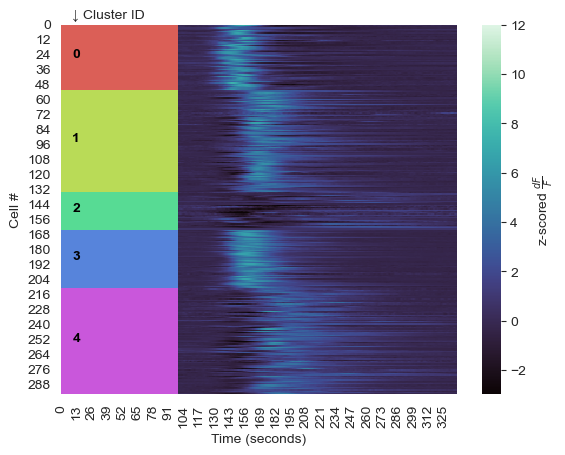

In [15]:
fig, ax = plt.subplots()

Ks=5 #What number of clusters are you plotting?
labels=umap_df['cluster_id']
cmap = sns.color_palette('hls', 5) #Change here the number of colors needed (# clusters)

# -> Cosmetic code to create a Rectangle patches to label specific K-cluster
Koffset = 0

sns.heatmap(result, cbar=True, cbar_kws={"label": r"z-scored $\frac{dF}{F}$"},cmap='mako',ax=ax, vmin=-3, vmax=12)
for Ki in range(Ks):
    Nk = np.size(np.where(labels == Ki))
    # 40 is width of the rectangle
    rect = mpl.patches.Rectangle((0, Koffset), 100, Nk, linewidth=1, edgecolor='none', facecolor=cmap[Ki])
    ax.text(10, Koffset + Nk/2, Ki ,color='k', weight='bold')
    # Add the patch to the plot
    ax.add_patch(rect)
    Koffset += Nk
ax.text(10,-5,'↓ Cluster ID',fontsize=10)
# <- end of cosmetic code
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Cell #')
# ax.set_xticks(np.linspace(0, result.shape[1], 12),
# labels=np.linspace(0, 330, 12, dtype=np.int))
# ax.set_yticks(np.linspace(0, result.shape[0], 10),
# labels=np.linspace(0, 250, 10, dtype=np.int))

In [44]:
#Do you want to look at a specific cluster? Look no further...
cluster0 = umap_df[umap_df['cluster_id']== 0]
numpy_list = [array for array in cluster0['waveform']]
cluster0 = np.vstack(numpy_list)

cluster1 = umap_df[umap_df['cluster_id']== 1]
numpy_list = [array for array in cluster1['waveform']]
cluster1 = np.vstack(numpy_list)

cluster2 = umap_df[umap_df['cluster_id']== 2]
numpy_list = [array for array in cluster2['waveform']]
cluster2 = np.vstack(numpy_list)

cluster3 = umap_df[umap_df['cluster_id']== 3]
numpy_list = [array for array in cluster3['waveform']]
cluster3 = np.vstack(numpy_list)


In [ ]:
#Save that cluster numpy array for future use
np.save('/Users/suthardr/Desktop/cluster0_cxta_fc_shock.npy', cluster1)

Text(52.722222222222214, 0.5, 'Cell #')

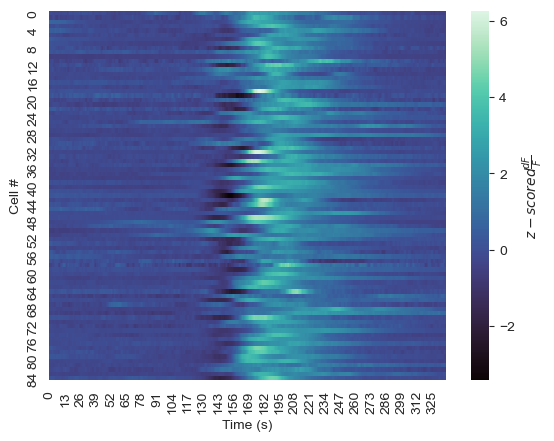

In [26]:
# Want to plot a heatmap for a specific cluster?

# Major ticks every 20, minor ticks every 5
fig, ax = plt.subplots()

sns.heatmap(cluster1, cbar=True, cbar_kws={"label": r"$z-scored \frac{dF}{F}$"}, cmap='mako', ax=ax)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cell #')
# ax.set_xticks(np.linspace(0, cluster0.shape[1], 12),
# labels=np.linspace(0, 330, 12, dtype=np.int))
# ax.set_yticks(np.linspace(0, cluster0.shape[0], 10),
# labels=np.linspace(0, 32, 10, dtype=np.int))

#Save that heatmap as a png because svg will blow up your laptop
#fig.savefig('/Users/suthardr/Desktop/recall_cxtb_heatmap_clusterzoom.png')


<Axes: >

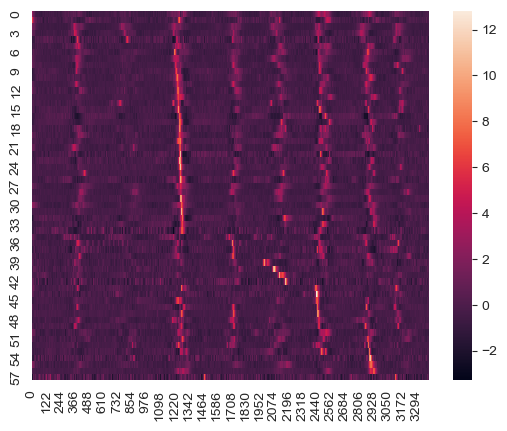

In [34]:
max_indices = np.argmax(cluster1, axis=1)
sorted_ind = np.argsort(max_indices)
sorted_arr = cluster1[sorted_ind]
sns.heatmap(sorted_arr)

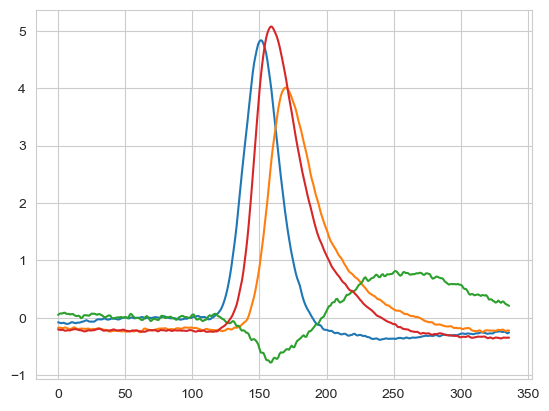

In [45]:
#Want to see what your average cluster plot looks like and find events?
plt.plot((np.average(cluster0, axis=0)))
plt.plot((np.average(cluster1, axis=0)))
plt.plot((np.average(cluster2, axis=0)))
plt.plot((np.average(cluster3, axis=0)))
# avg = np.average(cluster1, axis=0)
# peaks, properties = scipy.signal.find_peaks(avg, height=np.std(avg), distance=20, width=15, rel_height=0.5) #height =1 std, distance = 10Hz signal is 100ms/index, so 20 is 2 seconds,
#     #width = 140ms decay time for GCaMP so 1.4, rel_height = 0.5 or FWHM
# prominences = scipy.signal.peak_prominences(avg, peaks)[0]
# height = avg[peaks]-prominences
# properties #show the dictionary with the peak properties
#
#     #
# plt.figure()
# plt.plot(avg)
# plt.plot(peaks, avg[peaks], 'x')
# plt.ylabel('dF/F')
# plt.xlabel('Time (ms)')
# plt.vlines(x=peaks, ymin=height, ymax=avg[peaks], color='orange')